# Random Forest Analysis of Rain Effects on Seattle Bus Delay

This notebook focuses only on the Random Forest part of the project and keeps a clean experiment workflow.


## 1. Problem Setup and Notebook Roadmap

Goal:
- predict `delay_min`
- test whether rain-related features improve a Random Forest model
- analyze whether rain is associated with higher bus delay

Workflow:
1. load the model-ready dataset and engineer rain-related features
2. run descriptive dry-vs-rain analysis
3. define the main feature sets and train/test split
4. train baseline and weather-aware Random Forest models
5. interpret the full model with feature importance and SHAP
6. check dry-vs-rain prediction behavior
7. test imbalance handling with a balanced subset experiment
8. try improvement experiments and a professor-style compact feature set
9. summarize what the Random Forest experiments show


In [295]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP is not installed. Run `pip install shap` in your notebook environment to enable SHAP analysis.')

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

RANDOM_STATE = 42

path = '../data/processed/model_input.csv'
df = pd.read_csv(path)

if 'weather_category' not in df.columns:
    raise ValueError('Expected weather_category in model_input.csv')

df = df[df['weather_category'].isin(['dry', 'rain_light', 'rain_moderate'])].copy()
df['rain_group'] = df['weather_category'].replace({
    'rain_light': 'rain',
    'rain_moderate': 'rain',
})

df['rain_binary'] = (df['rain_group'] == 'rain').astype(int)
df['rain_peak'] = df['rain_binary'] * df['is_peak_hour']
df['rain_hour'] = df['rain_binary'] * df['hour_of_day']
df['rain_precip'] = df['rain_binary'] * df['precipitation_mm']

df['route_code'], route_labels = pd.factorize(df['route_short_name'])
df['peak_rain_interaction'] = df['is_peak_hour'] * df['is_raining']
df['hour_rain_interaction'] = df['hour_of_day'] * df['is_raining']
df['route_rain_interaction'] = df['route_code'] * df['is_raining']

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (20311, 24)
Columns: ['stop_id', 'route_id', 'route_short_name', 'delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'status', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining', 'weather_category', 'rain_group', 'rain_binary', 'rain_peak', 'rain_hour', 'rain_precip', 'route_code', 'peak_rain_interaction', 'hour_rain_interaction', 'route_rain_interaction']


,stop_id,route_id,route_short_name,delay_min,hour_of_day,day_of_week,is_weekend,is_peak_hour,status,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,is_raining,weather_category,rain_group,rain_binary,rain_peak,rain_hour,rain_precip,route_code,peak_rain_interaction,hour_rain_interaction,route_rain_interaction
0,1_10912,40_100511,542,0.00,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,0.0,0,0,0.0,0
1,1_65092,1_100162,271,-17.65,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,0.0,1,0,0.0,0
2,1_51930,1_100030,131,-3.80,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,0.0,2,0,0.0,0
3,1_46505,1_102619,F Line,-7.40,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,0.0,3,0,0.0,0
4,1_77460,1_102746,333,4.58,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,0.0,4,0,0.0,0


## 2. Descriptive Analysis: Dry vs Rain


In [296]:
summary = (
    df.groupby('rain_group')
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
          median_delay=('delay_min', 'median'),
          std_delay=('delay_min', 'std'),
          mean_precip_mm=('precipitation_mm', 'mean'),
          mean_temp_c=('temperature_c', 'mean'),
      )
      .round(2)
)
summary


,records,mean_delay,median_delay,std_delay,mean_precip_mm,mean_temp_c
rain_group,,,,,,
dry,17753,-0.00,0.0,5.64,0.00,7.80
rain,2558,0.37,0.0,5.48,2.44,10.29


In [297]:
peak_summary = (
    df.groupby(['is_peak_hour', 'rain_group'])
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
          median_delay=('delay_min', 'median'),
      )
      .round(2)
)
peak_summary.index = peak_summary.index.set_levels([
    ['non_rush', 'rush'] if level.name == 'is_peak_hour' else level
    for level in peak_summary.index.levels
])
peak_summary


records  mean_delay  median_delay
is_peak_hour rain_group                                   
non_rush     dry           10460        0.00           0.0
             rain           1513        0.33           0.0
rush         dry            7293       -0.01           0.0
             rain           1045        0.42           0.0

In [298]:
dow_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

day_summary = (
    df.assign(day_name=df['day_of_week'].map(dow_map))
      .groupby(['day_name', 'rain_group'])
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
      )
      .round(2)
)
day_summary


records  mean_delay
day_name rain_group                     
Fri      dry             964        0.19
         rain            186       -0.46
Mon      dry            6492       -0.19
Sat      dry            3064       -0.09
Sun      dry            2559        0.06
Thu      dry            1335        0.44
         rain            473        0.61
Tue      dry            2620        0.14
         rain            839        0.34
Wed      dry             719        0.30
         rain           1060        0.43

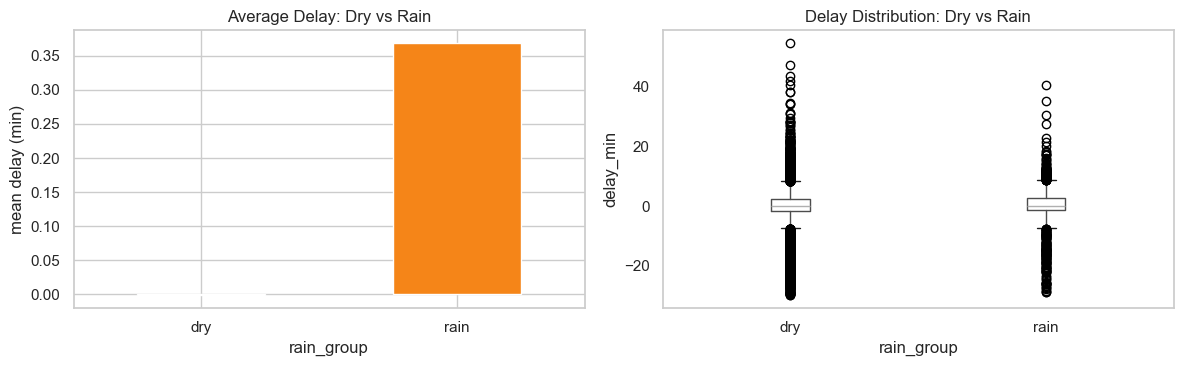

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('rain_group')['delay_min'].mean().plot(
    kind='bar', ax=axes[0], color=['#4c78a8', '#f58518'], rot=0
)
axes[0].set_title('Average Delay: Dry vs Rain')
axes[0].set_xlabel('rain_group')
axes[0].set_ylabel('mean delay (min)')

df.boxplot(column='delay_min', by='rain_group', ax=axes[1], grid=False)
axes[1].set_title('Delay Distribution: Dry vs Rain')
axes[1].set_xlabel('rain_group')
axes[1].set_ylabel('delay_min')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 3. Data Preparation and Main Feature Sets


In [300]:
target = 'delay_min'

time_num_features = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']
route_cat_features = ['route_short_name']
weather_num_features = ['temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining']
weather_cat_features = ['rain_group']
weather_detail_cat_features = ['weather_category']
interaction_num_features = ['rain_peak', 'rain_hour', 'rain_precip']

features_baseline = time_num_features + route_cat_features
features_full = time_num_features + route_cat_features + weather_num_features + weather_cat_features

X = df[features_full].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['rain_group'],
)

main_split_distribution = pd.DataFrame({
    'full_data': df['rain_group'].value_counts(normalize=True).round(4),
    'train': X_train['rain_group'].value_counts(normalize=True).round(4),
    'test': X_test['rain_group'].value_counts(normalize=True).round(4),
})

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)
main_split_distribution


Train size: (16248, 11)
Test size: (4063, 11)


,full_data,train,test
rain_group,,,
dry,0.8741,0.8741,0.874
rain,0.1259,0.1259,0.126


In [301]:
def build_preprocessor(feature_list):
    numeric_features = [
        col for col in feature_list
        if col in time_num_features + weather_num_features + interaction_num_features
    ]
    categorical_features = [
        col for col in feature_list
        if col in route_cat_features + weather_cat_features + weather_detail_cat_features
    ]

    return ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ]
    )


def make_rf_model():
    return RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def make_pipeline(feature_list):
    return Pipeline([
        ('preprocess', build_preprocessor(feature_list)),
        ('model', make_rf_model()),
    ])


def evaluate_model(label, feature_list, X_train_split, X_test_split, y_train_split, y_test_split):
    pipe = make_pipeline(feature_list)
    pipe.fit(X_train_split[feature_list], y_train_split)
    preds = pipe.predict(X_test_split[feature_list])

    return {
        'label': label,
        'pipe': pipe,
        'preds': preds,
        'r2': round(r2_score(y_test_split, preds), 4),
        'rmse': round(mean_squared_error(y_test_split, preds) ** 0.5, 4),
        'mae': round(mean_absolute_error(y_test_split, preds), 4),
    }


def run_experiment(label, df_input, stratify_col=None):
    X_local = df_input[features_full].copy()
    y_local = df_input[target].copy()

    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X_local,
        y_local,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=stratify_col,
    )

    rf_baseline_local = evaluate_model(
        'Random Forest baseline',
        features_baseline,
        X_train_local, X_test_local, y_train_local, y_test_local,
    )
    rf_full_local = evaluate_model(
        'Random Forest full',
        features_full,
        X_train_local, X_test_local, y_train_local, y_test_local,
    )

    results_local = pd.DataFrame([
        {k: v for k, v in rf_baseline_local.items() if k in ['label', 'r2', 'rmse', 'mae']},
        {k: v for k, v in rf_full_local.items() if k in ['label', 'r2', 'rmse', 'mae']},
    ])
    results_local['experiment'] = label

    return {
        'X_train': X_train_local,
        'X_test': X_test_local,
        'y_train': y_train_local,
        'y_test': y_test_local,
        'rf_baseline': rf_baseline_local,
        'rf_full': rf_full_local,
        'results': results_local,
    }


## 4. Main Models: Random Forest Baseline vs Full


In [302]:
rf_baseline_run = evaluate_model(
    'Random Forest baseline',
    features_baseline,
    X_train, X_test, y_train, y_test,
)
rf_full_run = evaluate_model(
    'Random Forest full',
    features_full,
    X_train, X_test, y_train, y_test,
)

rf_results = pd.DataFrame([
    {k: v for k, v in rf_baseline_run.items() if k in ['label', 'r2', 'rmse', 'mae']},
    {k: v for k, v in rf_full_run.items() if k in ['label', 'r2', 'rmse', 'mae']},
])
rf_results


,label,r2,rmse,mae
0,Random Forest baseline,0.2485,5.0034,3.3380
1,Random Forest full,0.2354,5.0467,3.3601


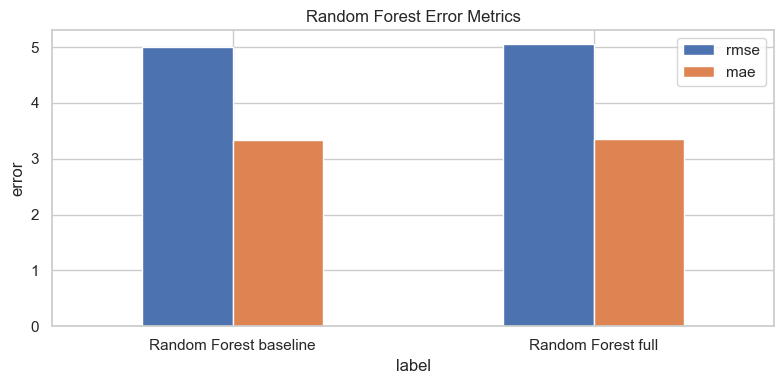

In [303]:
ax = rf_results.set_index('label')[['rmse', 'mae']].plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_title('Random Forest Error Metrics')
ax.set_ylabel('error')
plt.tight_layout()
plt.show()


## 5. Main-Model Interpretation


In [304]:
rf_full_preprocessor = rf_full_run['pipe'].named_steps['preprocess']
rf_full_model = rf_full_run['pipe'].named_steps['model']
rf_feature_names = rf_full_preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': rf_full_model.feature_importances_,
}).sort_values('importance', ascending=False)
importances.head(20)


,feature,importance
100,cat__route_short_name_62,0.198229
35,cat__route_short_name_165,0.145596
43,cat__route_short_name_2,0.127796
39,cat__route_short_name_181,0.088522
6,num__wind_speed_kmh,0.079264
0,num__hour_of_day,0.077776
4,num__temperature_c,0.058354
28,cat__route_short_name_148,0.052959
1,num__day_of_week,0.033928
34,cat__route_short_name_162,0.032764


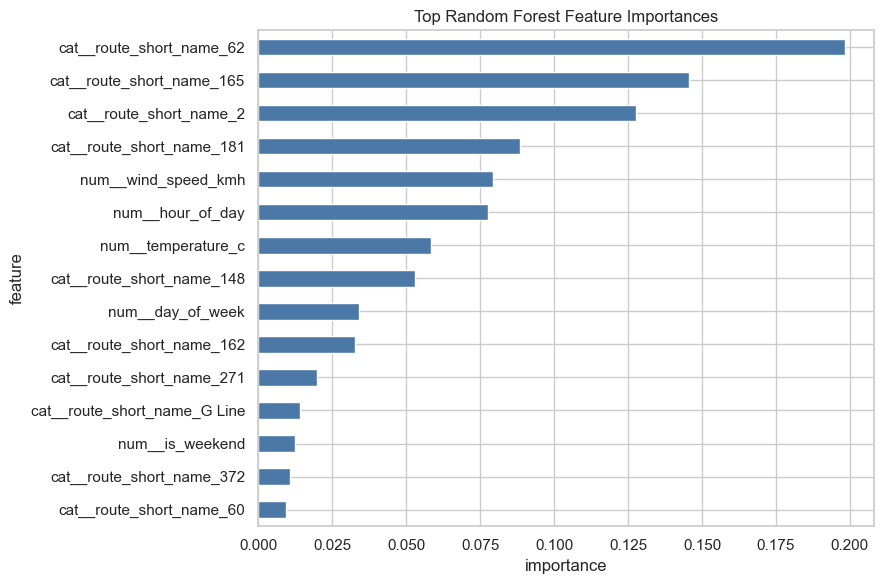

In [305]:
top_importances = importances.head(15).sort_values('importance')
ax = top_importances.plot(kind='barh', x='feature', y='importance', figsize=(9, 6), legend=False, color='#4c78a8')
ax.set_title('Top Random Forest Feature Importances')
ax.set_xlabel('importance')
ax.set_ylabel('feature')
plt.tight_layout()
plt.show()


### 5.1 SHAP on the Main Full Random Forest


In [306]:
if not SHAP_AVAILABLE:
    raise ImportError('Install shap in the notebook kernel: pip install shap')

rf_full_X_test_transformed = rf_full_preprocessor.transform(X_test[features_full])
if hasattr(rf_full_X_test_transformed, 'toarray'):
    rf_full_X_test_transformed = rf_full_X_test_transformed.toarray()

sample_size = min(1000, rf_full_X_test_transformed.shape[0])
sample_idx = np.random.default_rng(RANDOM_STATE).choice(rf_full_X_test_transformed.shape[0], size=sample_size, replace=False)
X_shap_sample = rf_full_X_test_transformed[sample_idx]

explainer = shap.TreeExplainer(rf_full_model)
shap_values = explainer.shap_values(X_shap_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

X_shap_df = pd.DataFrame(X_shap_sample, columns=rf_feature_names)
print('SHAP sample shape:', X_shap_df.shape)
X_shap_df.head()


SHAP sample shape: (1000, 123)


,num__hour_of_day,num__day_of_week,num__is_weekend,num__is_peak_hour,num__temperature_c,num__precipitation_mm,num__wind_speed_kmh,num__weather_code,num__is_raining,cat__route_short_name_1,cat__route_short_name_10,cat__route_short_name_101,cat__route_short_name_102,cat__route_short_name_105,cat__route_short_name_106,cat__route_short_name_107,cat__route_short_name_11,cat__route_short_name_111,cat__route_short_name_113,cat__route_short_name_118,cat__route_short_name_12,cat__route_short_name_124,cat__route_short_name_125,cat__route_short_name_128,cat__route_short_name_13,cat__route_short_name_131,cat__route_short_name_132,cat__route_short_name_14,cat__route_short_name_148,cat__route_short_name_150,cat__route_short_name_153,cat__route_short_name_156,cat__route_short_name_160,cat__route_short_name_161,cat__route_short_name_162,cat__route_short_name_165,cat__route_short_name_168,cat__route_short_name_17,cat__route_short_name_177,cat__route_short_name_181,cat__route_short_name_183,cat__route_short_name_184,cat__route_short_name_187,cat__route_short_name_2,cat__route_short_name_203,cat__route_short_name_208,cat__route_short_name_21,cat__route_short_name_212,cat__route_short_name_218,cat__route_short_name_22,...,cat__route_short_name_333,cat__route_short_name_345,cat__route_short_name_346,cat__route_short_name_348,cat__route_short_name_36,cat__route_short_name_365,cat__route_short_name_372,cat__route_short_name_4,cat__route_short_name_40,cat__route_short_name_43,cat__route_short_name_44,cat__route_short_name_45,cat__route_short_name_48,cat__route_short_name_49,cat__route_short_name_5,cat__route_short_name_50,cat__route_short_name_522,cat__route_short_name_542,cat__route_short_name_545,cat__route_short_name_550,cat__route_short_name_554,cat__route_short_name_556,cat__route_short_name_56,cat__route_short_name_566,cat__route_short_name_57,cat__route_short_name_60,cat__route_short_name_61,cat__route_short_name_62,cat__route_short_name_65,cat__route_short_name_67,cat__route_short_name_7,cat__route_short_name_70,cat__route_short_name_75,cat__route_short_name_79,cat__route_short_name_8,cat__route_short_name_9,cat__route_short_name_986,cat__route_short_name_987,cat__route_short_name_988,cat__route_short_name_A Line,cat__route_short_name_B Line,cat__route_short_name_C Line,cat__route_short_name_D Line,cat__route_short_name_E Line,cat__route_short_name_F Line,cat__route_short_name_First Hill Streetcar,cat__route_short_name_G Line,cat__route_short_name_H Line,cat__rain_group_dry,cat__rain_group_rain
0,20.0,1.0,0.0,0.0,5.4,0.0,20.1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,12.0,0.0,0.0,0.0,7.2,0.0,20.6,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,15.0,0.0,0.0,0.0,7.3,0.0,21.5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,12.0,0.0,0.0,0.0,9.1,0.0,17.4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [307]:
shap_importance = pd.DataFrame({
    'feature': rf_feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)
shap_importance.head(20)


,feature,mean_abs_shap
35,cat__route_short_name_165,0.354696
100,cat__route_short_name_62,0.351633
39,cat__route_short_name_181,0.343697
43,cat__route_short_name_2,0.338793
28,cat__route_short_name_148,0.166016
0,num__hour_of_day,0.133749
65,cat__route_short_name_271,0.107387
6,num__wind_speed_kmh,0.105289
1,num__day_of_week,0.097079
79,cat__route_short_name_372,0.094261


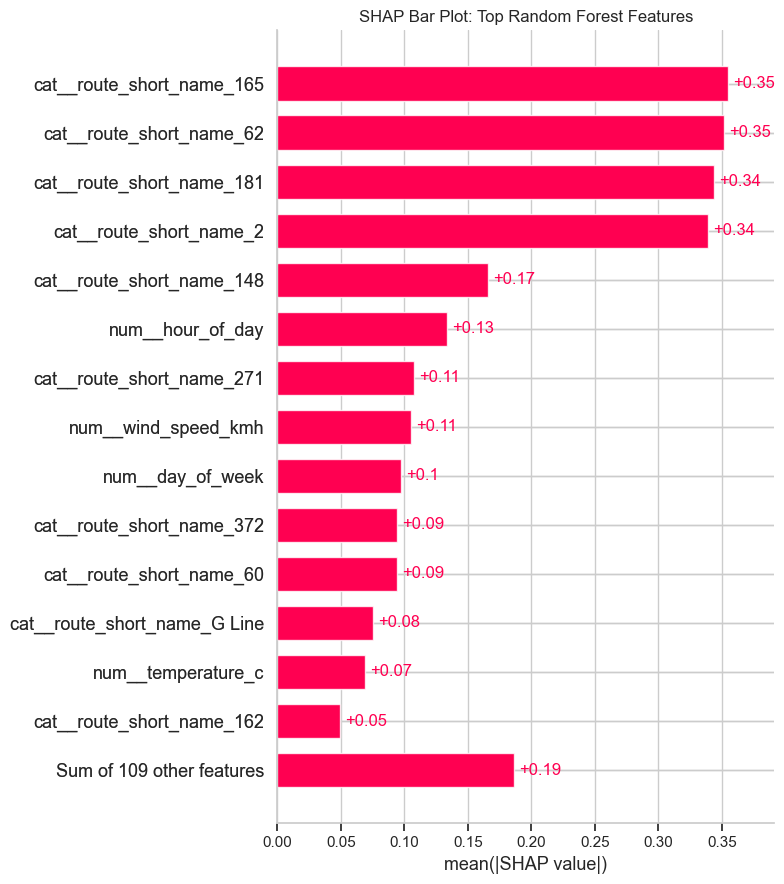

In [308]:
plt.figure(figsize=(9, 6))
shap.plots.bar(shap.Explanation(values=shap_values, data=X_shap_sample, feature_names=rf_feature_names), max_display=15, show=False)
plt.title('SHAP Bar Plot: Top Random Forest Features')
plt.tight_layout()
plt.show()


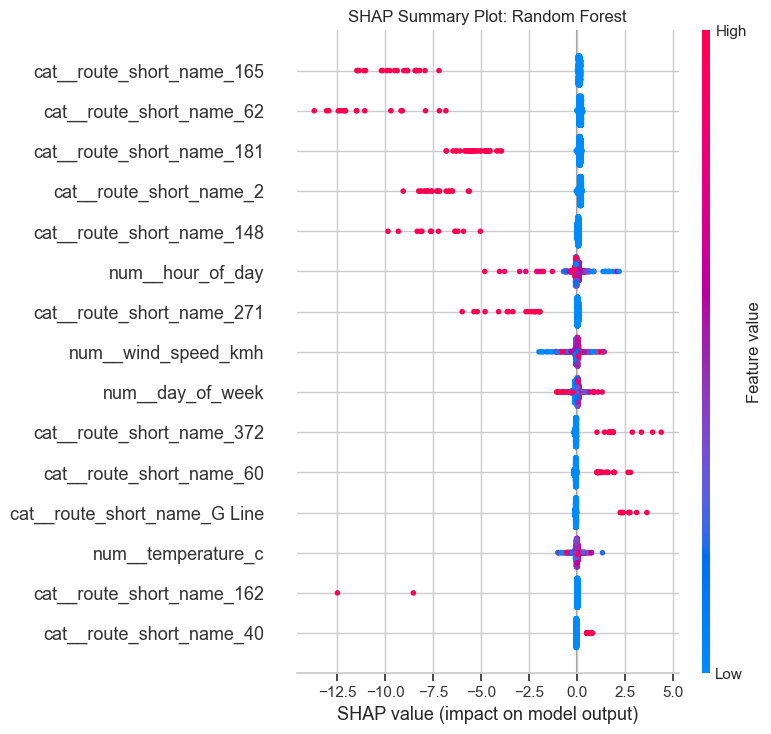

In [309]:
shap.summary_plot(shap_values, X_shap_df, max_display=15, show=False)
plt.title('SHAP Summary Plot: Random Forest')
plt.tight_layout()
plt.show()


In [310]:
rain_related_shap = shap_importance[shap_importance['feature'].str.contains('precipitation_mm|weather_code|is_raining|rain_group')].copy()
rain_related_shap


,feature,mean_abs_shap
7,num__weather_code,0.012602
5,num__precipitation_mm,0.009119
121,cat__rain_group_dry,0.004238
122,cat__rain_group_rain,0.001415
8,num__is_raining,0.001136


Interpretation guide for the main SHAP analysis:
- If route one-hot features still dominate SHAP, route identity explains more variance than weather.
- If `precipitation_mm`, `weather_code`, `is_raining`, or `rain_group_rain` have low mean |SHAP|, that matches the weak improvement from adding weather to the model.
- Use SHAP together with the descriptive dry-vs-rain summaries: even if rain shifts average delay upward, the effect may still be small relative to route-level variation.


## 6. Dry-vs-Rain Prediction Diagnostics


In [311]:
test_analysis = X_test.copy()
test_analysis['actual_delay'] = y_test.values
test_analysis['baseline_pred'] = rf_baseline_run['preds']
test_analysis['full_pred'] = rf_full_run['preds']

rain_prediction_summary = (
    test_analysis.groupby('rain_group')
      .agg(
          records=('actual_delay', 'count'),
          actual_mean_delay=('actual_delay', 'mean'),
          baseline_pred_mean=('baseline_pred', 'mean'),
          full_pred_mean=('full_pred', 'mean'),
      )
      .round(2)
)
rain_prediction_summary


,records,actual_mean_delay,baseline_pred_mean,full_pred_mean
rain_group,,,,
dry,3551,-0.06,0.00,-0.01
rain,512,0.42,0.16,0.22


In [312]:
peak_rain_prediction = (
    test_analysis.groupby(['is_peak_hour', 'rain_group'])
      .agg(
          records=('actual_delay', 'count'),
          actual_mean_delay=('actual_delay', 'mean'),
          full_pred_mean=('full_pred', 'mean'),
      )
      .round(2)
)
peak_rain_prediction.index = peak_rain_prediction.index.set_levels([
    ['non_rush', 'rush'] if level.name == 'is_peak_hour' else level
    for level in peak_rain_prediction.index.levels
])
peak_rain_prediction


records  actual_mean_delay  full_pred_mean
is_peak_hour rain_group                                            
non_rush     dry            2118               0.05            0.02
             rain            303               0.26            0.15
rush         dry            1433              -0.22           -0.06
             rain            209               0.65            0.31

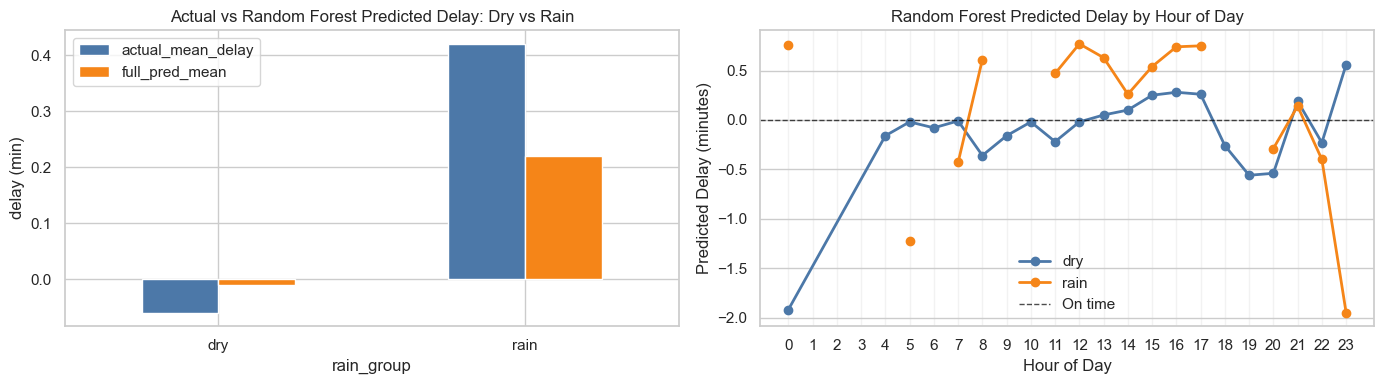

In [313]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rain_prediction_summary[['actual_mean_delay', 'full_pred_mean']].plot(
    kind='bar', ax=axes[0], color=['#4c78a8', '#f58518'], rot=0
)
axes[0].set_title('Actual vs Random Forest Predicted Delay: Dry vs Rain')
axes[0].set_ylabel('delay (min)')
axes[0].set_xlabel('rain_group')

hourly_pred = (
    test_analysis.groupby(['hour_of_day', 'rain_group'])['full_pred']
      .mean()
      .unstack()
      .round(2)
)
for col, color in [('dry', '#4c78a8'), ('rain', '#f58518')]:
    if col in hourly_pred.columns:
        axes[1].plot(hourly_pred.index, hourly_pred[col], marker='o', linewidth=2, color=color, label=col)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='On time')
axes[1].set_title('Random Forest Predicted Delay by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Predicted Delay (minutes)')
axes[1].set_xticks(range(24))
axes[1].grid(True, axis='x', alpha=0.25)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 7. Imbalance Check: Balanced Subset Experiment


In [314]:
rain_df = df[df['rain_group'] == 'rain'].copy()
dry_df = df[df['rain_group'] == 'dry'].sample(n=len(rain_df), random_state=RANDOM_STATE).copy()
balanced_df = pd.concat([dry_df, rain_df], ignore_index=True)
balanced_df['rain_group'].value_counts()


rain_group
dry     2558
rain    2558
Name: count, dtype: int64

In [315]:
balanced_run = run_experiment('balanced_subset', balanced_df, stratify_col=balanced_df['rain_group'])
balanced_results = balanced_run['results']
balanced_results


,label,r2,rmse,mae,experiment
0,Random Forest baseline,0.2378,4.8675,3.2681,balanced_subset
1,Random Forest full,0.2310,4.8892,3.2701,balanced_subset


In [316]:
original_results = rf_results.copy()
original_results['experiment'] = 'original_stratified'
combined_results = pd.concat([original_results, balanced_results], ignore_index=True)
combined_results = combined_results[['experiment', 'label', 'r2', 'rmse', 'mae']]
combined_results.sort_values(['experiment', 'rmse'])


,experiment,label,r2,rmse,mae
2,balanced_subset,Random Forest baseline,0.2378,4.8675,3.2681
3,balanced_subset,Random Forest full,0.2310,4.8892,3.2701
0,original_stratified,Random Forest baseline,0.2485,5.0034,3.3380
1,original_stratified,Random Forest full,0.2354,5.0467,3.3601


In [317]:
balanced_test = balanced_run['X_test'].copy()
balanced_test['actual_delay'] = balanced_run['y_test'].values
balanced_test['full_pred'] = balanced_run['rf_full']['preds']
balanced_rain_summary = (
    balanced_test.groupby('rain_group')
      .agg(
          records=('actual_delay', 'count'),
          actual_mean_delay=('actual_delay', 'mean'),
          pred_mean_delay=('full_pred', 'mean'),
      )
      .round(2)
)
balanced_rain_summary


,records,actual_mean_delay,pred_mean_delay
rain_group,,,
dry,512,-0.09,-0.24
rain,512,0.75,0.37


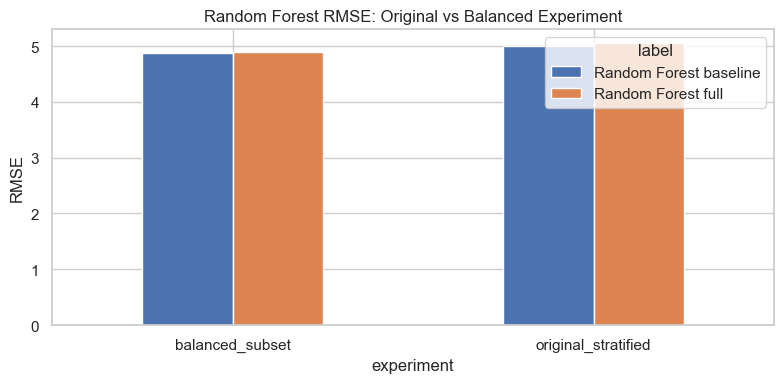

In [318]:
ax = combined_results.pivot(index='experiment', columns='label', values='rmse').plot(
    kind='bar', figsize=(8, 4), rot=0
)
ax.set_title('Random Forest RMSE: Original vs Balanced Experiment')
ax.set_ylabel('RMSE')
plt.tight_layout()
plt.show()


How to read the balanced-subset section:
- If rain-related features become more useful in the balanced subset, the original imbalance was suppressing the rain signal.
- If they still remain weak, then route and time effects dominate even after balancing.


## 8. Improvement Experiments


In [319]:
features_richer_with_route = (
    time_num_features
    + weather_num_features
    + interaction_num_features
    + route_cat_features
    + weather_detail_cat_features
)

features_richer_no_route = (
    time_num_features
    + weather_num_features
    + interaction_num_features
    + weather_detail_cat_features
)


def run_rf_variant(label, feature_list, target_series, stratify_col):
    X_local = df[feature_list].copy()
    y_local = target_series.copy()

    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X_local,
        y_local,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=stratify_col,
    )

    pipe = make_pipeline(feature_list)
    pipe.fit(X_train_local, y_train_local)
    preds = pipe.predict(X_test_local)

    return {
        'label': label,
        'features': feature_list,
        'X_test': X_test_local,
        'y_test': y_test_local,
        'preds': preds,
        'r2': round(r2_score(y_test_local, preds), 4),
        'rmse': round(mean_squared_error(y_test_local, preds) ** 0.5, 4),
        'mae': round(mean_absolute_error(y_test_local, preds), 4),
    }


In [320]:
delay_clipped = df['delay_min'].clip(-20, 20)

rf_variants = [
    run_rf_variant('current_full_with_route', features_full, df['delay_min'], df['rain_group']),
    run_rf_variant('richer_weather_with_route', features_richer_with_route, df['delay_min'], df['rain_group']),
    run_rf_variant('richer_weather_no_route', features_richer_no_route, df['delay_min'], df['rain_group']),
    run_rf_variant('richer_weather_no_route_clipped_target', features_richer_no_route, delay_clipped, df['rain_group']),
]

rf_variant_results = pd.DataFrame([{
    'label': run['label'],
    'n_features': len(run['features']),
    'r2': run['r2'],
    'rmse': run['rmse'],
    'mae': run['mae'],
} for run in rf_variants]).sort_values('rmse')
rf_variant_results


,label,n_features,r2,rmse,mae
0,current_full_with_route,11,0.2354,5.0467,3.3601
1,richer_weather_with_route,14,0.2351,5.0479,3.3606
3,richer_weather_no_route_clipped_target,13,0.0084,5.3613,3.3956
2,richer_weather_no_route,13,0.0076,5.7496,3.4975


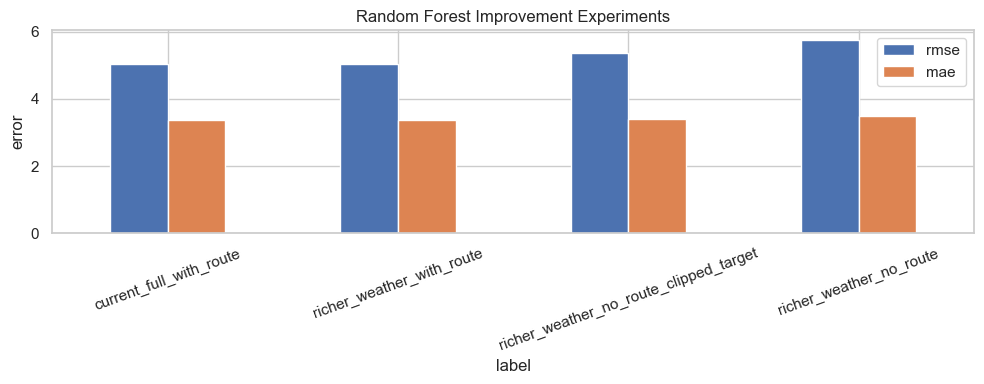

In [321]:
ax = rf_variant_results.set_index('label')[['rmse', 'mae']].plot(kind='bar', figsize=(10, 4), rot=20)
ax.set_title('Random Forest Improvement Experiments')
ax.set_ylabel('error')
plt.tight_layout()
plt.show()


In [322]:
variant_prediction_summary = []
for run in rf_variants:
    temp = run['X_test'].copy()
    if 'rain_group' not in temp.columns:
        temp['rain_group'] = df.loc[temp.index, 'rain_group'].values
    temp['actual_delay'] = run['y_test'].values
    temp['pred_delay'] = run['preds']
    summary = temp.groupby('rain_group').agg(
        records=('actual_delay', 'count'),
        actual_mean_delay=('actual_delay', 'mean'),
        pred_mean_delay=('pred_delay', 'mean'),
    ).round(2)
    summary['label'] = run['label']
    variant_prediction_summary.append(summary.reset_index())

variant_prediction_summary = pd.concat(variant_prediction_summary, ignore_index=True)
variant_prediction_summary


,rain_group,records,actual_mean_delay,pred_mean_delay,label
0,dry,3551,-0.06,-0.01,current_full_with_route
1,rain,512,0.42,0.22,current_full_with_route
2,dry,3551,-0.06,-0.02,richer_weather_with_route
3,rain,512,0.42,0.22,richer_weather_with_route
4,dry,3551,-0.06,0.01,richer_weather_no_route
5,rain,512,0.42,0.34,richer_weather_no_route
6,dry,3551,-0.03,0.04,richer_weather_no_route_clipped_target
7,rain,512,0.45,0.37,richer_weather_no_route_clipped_target


### 8.1 What these improvement experiments are testing

- We are no longer using only a binary rain indicator. The richer-weather variants explicitly keep `rain_light`, `rain_moderate`, and `precipitation_mm`.
- The interaction terms `rain_peak`, `rain_hour`, and `rain_precip` test whether rain becomes more harmful during peak hours or at certain times of day.
- The no-route comparison tests whether route identity is overpowering weather information and causing route overfitting.
- The clipped-target version tests whether extreme delays are masking the more typical rain effect.


How to read the improvement variants:
- `richer_weather_with_route`: keeps route information, but replaces the coarse weather setup with `weather_category` plus interaction terms.
- `richer_weather_no_route`: removes `route_short_name` to test whether route one-hot features were masking the rain signal.
- `richer_weather_no_route_clipped_target`: also clips `delay_min` to `[-20, 20]` so extreme delay values do not dominate the fit.


## 9. Professor-Style Compact Feature Set


In [323]:
professor_features = [
    'route_code',
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'is_peak_hour',
    'is_raining',
    'precipitation_mm',
    'peak_rain_interaction',
    'hour_rain_interaction',
    'route_rain_interaction',
]


def run_professor_variant(label, target_series):
    X_local = df[professor_features].copy()
    y_local = target_series.copy()

    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X_local,
        y_local,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=df['rain_group'],
    )

    model = make_rf_model()
    model.fit(X_train_local, y_train_local)
    preds = model.predict(X_test_local)

    return {
        'label': label,
        'model': model,
        'X_test': X_test_local,
        'y_test': y_test_local,
        'preds': preds,
        'r2': round(r2_score(y_test_local, preds), 4),
        'rmse': round(mean_squared_error(y_test_local, preds) ** 0.5, 4),
        'mae': round(mean_absolute_error(y_test_local, preds), 4),
    }


In [324]:
professor_run = run_professor_variant('professor_feature_set', df['delay_min'])
professor_run_clipped = run_professor_variant('professor_feature_set_clipped_target', df['delay_min'].clip(-20, 20))

professor_results = pd.DataFrame([
    {k: v for k, v in professor_run.items() if k in ['label', 'r2', 'rmse', 'mae']},
    {k: v for k, v in professor_run_clipped.items() if k in ['label', 'r2', 'rmse', 'mae']},
])
professor_results


,label,r2,rmse,mae
0,professor_feature_set,0.2731,4.9207,3.2635
1,professor_feature_set_clipped_target,0.2685,4.6046,3.1702


In [325]:
professor_importance = pd.DataFrame({
    'feature': professor_features,
    'importance': professor_run['model'].feature_importances_,
}).sort_values('importance', ascending=False)
professor_importance


,feature,importance
0,route_code,0.694024
1,hour_of_day,0.164897
2,day_of_week,0.082912
3,is_weekend,0.020282
4,is_peak_hour,0.015497
6,precipitation_mm,0.009199
8,hour_rain_interaction,0.007628
9,route_rain_interaction,0.003367
7,peak_rain_interaction,0.001659
5,is_raining,0.000536


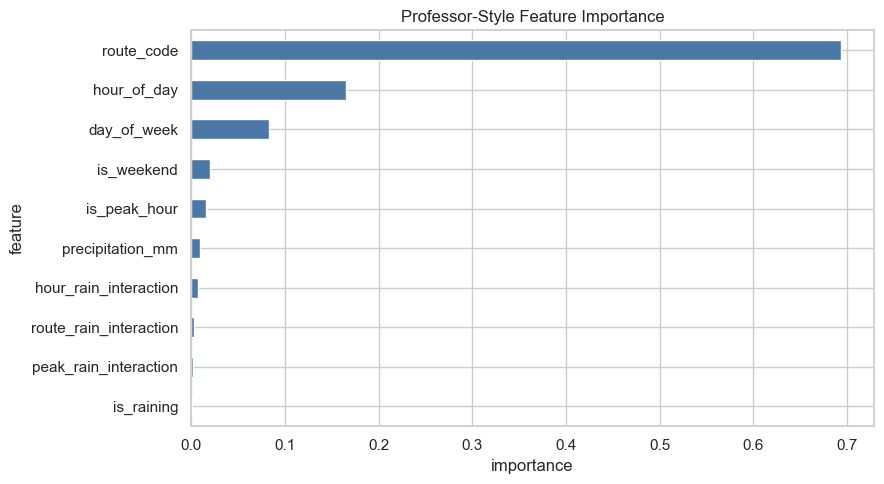

In [326]:
ax = professor_importance.sort_values('importance').plot(
    kind='barh', x='feature', y='importance', figsize=(9, 5), legend=False, color='#4c78a8'
)
ax.set_title('Professor-Style Feature Importance')
ax.set_xlabel('importance')
ax.set_ylabel('feature')
plt.tight_layout()
plt.show()


In [327]:
professor_summary_rows = []
for run in [professor_run, professor_run_clipped]:
    temp = run['X_test'].copy()
    temp['rain_group'] = df.loc[temp.index, 'rain_group'].values
    temp['actual_delay'] = run['y_test'].values
    temp['pred_delay'] = run['preds']
    summary = temp.groupby('rain_group').agg(
        records=('actual_delay', 'count'),
        actual_mean_delay=('actual_delay', 'mean'),
        pred_mean_delay=('pred_delay', 'mean'),
    ).round(2)
    summary['label'] = run['label']
    professor_summary_rows.append(summary.reset_index())

professor_prediction_summary = pd.concat(professor_summary_rows, ignore_index=True)
professor_prediction_summary


,rain_group,records,actual_mean_delay,pred_mean_delay,label
0,dry,3551,-0.06,-0.06,professor_feature_set
1,rain,512,0.42,0.44,professor_feature_set
2,dry,3551,-0.03,-0.03,professor_feature_set_clipped_target
3,rain,512,0.45,0.48,professor_feature_set_clipped_target


How to interpret the professor-style compact setup:
- `route_code` compresses route identity into one numeric feature, which is simpler than one-hot route columns but introduces an ordinal approximation.
- `route_rain_interaction` directly tests whether the rain effect varies by route.
- `peak_rain_interaction` and `hour_rain_interaction` directly test whether rain is worse during peak periods or at certain times.
- Compare `professor_feature_set` against `professor_feature_set_clipped_target` to see whether extreme delays are distorting the interaction signal.


## 10. Presentation Summary


### 10.1 Experiment flow: what we designed and why

We organized the Random Forest experiment in this order:

1. **Problem setup**
   - Goal: predict `delay_min` and test whether rain helps explain bus delay.
   - Model choice: use Random Forest as the main predictive model, because it is more stable than a single tree and can capture nonlinear patterns.

2. **Data preparation**
   - Use `model_input.csv`.
   - Keep the main weather comparison as `dry` vs `rain`, where `rain = rain_light + rain_moderate`.
   - Use a stratified train/test split so the dry-rain ratio stays consistent across train and test.

3. **Main model design**
   - Compare two versions:
     - `baseline`: time + route
     - `full`: time + route + weather
   - Use the same Random Forest settings across experiments to make the comparisons fair.

4. **Evaluation design**
   - Start with the single stratified train/test split.
   - Then test whether the rain signal changes under a balanced subset.
   - Then run richer-weather, no-route, clipped-target, and compact-feature experiments to check whether feature design is limiting the result.

5. **Interpretation design**
   - Inspect feature importance and SHAP.
   - Compare actual vs predicted delay for `dry` and `rain`.
   - Use the later experiments to distinguish between imbalance, feature design, and route dominance.


### 10.2 Problems we encountered and how we handled them

During the Random Forest experiment, several issues became clear:

- **Rain vs dry is imbalanced**
  - There are many more dry records than rain records.
  - We handled this first with a stratified split, and then tested a balanced subset experiment.

- **Route features can dominate the model**
  - Route identity is a very strong predictor, which can make weather effects look smaller.
  - We addressed this by checking feature importance, SHAP, and no-route variants.

- **Weather may be represented too coarsely**
  - A simple rain/no-rain label may miss useful detail.
  - We therefore tested richer weather features, interaction terms, and a compact professor-style feature set.

- **Extreme delays can distort regression behavior**
  - Large delay values may add noise and hide more typical patterns.
  - We tested a clipped-target version to see whether that changes the result.


### 10.3 What we tested, what results we got, and what to say

Following the experimental order, the main findings are:

1. **Descriptive analysis**
   - Rain is associated with slightly higher average delay than dry conditions.
   - This means the rain effect is visible in the raw data directionally.

2. **Main Random Forest comparison**
   - The baseline Random Forest performs slightly better than the full weather-aware Random Forest.
   - So adding weather features does not improve prediction in the main setup.

3. **SHAP and feature importance**
   - The model is dominated by route-related and time-related variables.
   - Weather-related variables contribute less, which is consistent with the weaker performance of the full model.

4. **Dry vs rain prediction check**
   - The model predictions are consistent with the same directional pattern seen in the descriptive analysis: predicted delay is higher under rain than under dry conditions.

5. **Balanced subset experiment**
   - If the balanced subset still shows weak weather contribution, then the result is not just caused by dry-rain imbalance.

6. **Improvement experiments**
   - Richer weather features, interaction terms, clipped targets, and the compact feature set test whether the weak rain signal is due to feature design.
   - If these variants still fail to improve prediction materially, that strengthens the conclusion that route and time remain more important than weather.

Final conclusion:
- Random Forest is the main predictive model in this analysis.
- Rain is associated with higher delay in the data, but route and time features are stronger drivers of bus delay than weather in this dataset.
- Adding weather features does not consistently improve Random Forest performance in the current experiments.


### 10.4 Presentation Draft

A concise version:

- "We used Random Forest as the main predictive model for bus delay."

- "The descriptive analysis shows that rain is associated with somewhat higher average delay."

- "However, the baseline Random Forest performs slightly better than the weather-aware version, so weather does not add much predictive value in the main setup."

- "Feature importance and SHAP show that route and time features are stronger predictors than weather features in this dataset."

- "Additional experiments help us test whether that result is caused by imbalance, feature design, or route dominance."

- "Overall, rain has a directional effect, but it is not the dominant driver of prediction performance in this dataset."
